In [1]:
import pandas as pd

df = pd.read_csv("done_labeling_2500_svm.csv")
df.head()

,processed_text,sentiment
0,duitnya dipake buat tahun baruan hidup korupto...,negatif
1,jangan sebut tanggapan misbahun bin satan angg...,negatif
2,beh indonesia negri birokrasi pasien mau berob...,negatif
3,guys nurunin inflasi itu tak mudah guys pak pu...,netral
4,indondesh banyak pakai pemimpin bodoh,negatif


In [2]:
df_full = pd.read_csv("full_labeling.csv")

labeled_text = set(
    df["processed_text"]
)

unlabeled_df = df_full[
    ~df_full["processed_text"]
    .isin(labeled_text)
]

In [3]:
print(len(df))
print(len(df_full))
print(len(unlabeled_df))

2500
18093
15685


In [4]:
label_map = {
    "negatif":0,
    "positif":1,
    "netral":2,

}

df["label"] = df["sentiment"].map(label_map)

In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2),
    min_df=2,
    max_df=0.95
)

X = vectorizer.fit_transform(df["processed_text"])

y = df["label"]

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    stratify=y,
    random_state=42
)

from sklearn.svm import LinearSVC

model_svm = LinearSVC()
model_svm.fit(X_train, y_train)

y_pred_svm = model_svm.predict(X_test)

In [7]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred_svm,
    )
)

              precision    recall  f1-score   support

           0       0.80      0.94      0.86       418
           1       0.63      0.35      0.45        68
           2       0.75      0.50      0.60       139

    accuracy                           0.78       625
   macro avg       0.73      0.60      0.64       625
weighted avg       0.77      0.78      0.76       625



In [8]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred_svm,
        target_names=[
            "negatif",
            "positf",
            "netral"
        ]
    )
)

              precision    recall  f1-score   support

     negatif       0.80      0.94      0.86       418
      positf       0.63      0.35      0.45        68
      netral       0.75      0.50      0.60       139

    accuracy                           0.78       625
   macro avg       0.73      0.60      0.64       625
weighted avg       0.77      0.78      0.76       625



<Axes: >

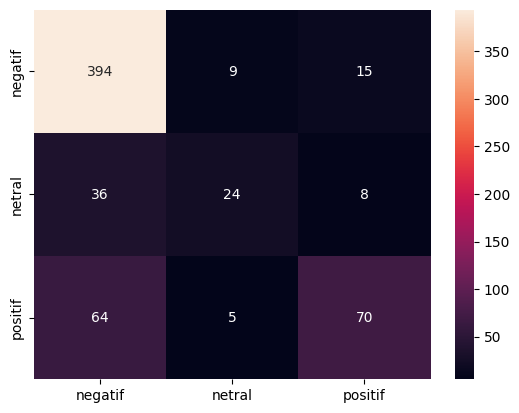

In [9]:
from sklearn.metrics import confusion_matrix

cm_svm = confusion_matrix(
    y_test,
    y_pred_svm
)

import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(
    cm_svm,
    annot=True,
    fmt="d",
    xticklabels=["negatif", "netral", "positif"],
    yticklabels=["negatif", "netral", "positif"]

)

<Axes: >

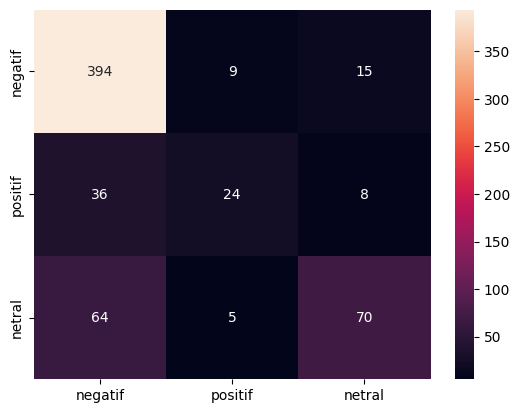

In [10]:
from sklearn.metrics import confusion_matrix

cm_svm = confusion_matrix(
    y_test,
    y_pred_svm
)

import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(
    cm_svm,
    annot=True,
    fmt="d",
    xticklabels=["negatif", "positif", "netral"],
    yticklabels=["negatif", "positif", "netral"]

)

In [11]:
X_unlabeled = vectorizer.transform(
    unlabeled_df['processed_text']
)

predictions = model_svm.predict(
    X_unlabeled
)

reverse_map = {
    0: "negatif",
    1: "netral",
    2: "positif"
}

unlabeled_df["sentiment"] = [
    reverse_map[x]
    for x in predictions
]

print(
    unlabeled_df["sentiment"].value_counts()
)

sentiment
negatif    12134
positif     2591
netral       960
Name: count, dtype: int64


In [12]:
unlabeled_df.to_csv(
    "done_labeling_15k_svm.csv",
    index=False
)

In [13]:
df_merge = pd.concat(
    [
        df[["processed_text", "sentiment"]],
        unlabeled_df[["processed_text", "sentiment"]]
    ],
    ignore_index=True
)

print(
    df_merge["sentiment"].value_counts()
)

sentiment
negatif    13807
positif     2862
netral      1516
Name: count, dtype: int64


In [14]:
df_merge.to_csv(
    "18k_done_sentiment.csv",
    index=False
)

CLOUDWORD

In [15]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer()

X_neg = cv.fit_transform(
    df_merge[df_merge["sentiment"]=="negatif"]["processed_text"]
    )

neg_freq = pd.DataFrame({
    "word": cv.get_feature_names_out(),
    "freq": X_neg.sum(axis=0).A1
})

neg_freq.sort_values("freq", ascending=False).head(50)



,word,freq
24199,yang,7435
22857,tidak,6042
4941,di,5301
4634,dan,5247
8749,indonesia,3140
8849,ini,2931
15403,negara,2652
12567,makan,2453
9132,itu,2409
19777,saja,2388


In [21]:
custom_stopwords = [
    "yang",
    "tidak",
    "di",
    "dan",
    "ini",
    "itu",
    "sudah",
    "saja",
    "dari",
    "kalau",
    "ada",
    "bisa",
    "tapi",
    "nya",
    "ke",
    "jadi",
    "karena",
    "lagi",
    "naik",
    "dengan",
    "untuk",
    "akan",
    "semua",
    "sama",
    "juga",
    "lebih",
    "lain",
    "pada",
    "masih",
    "ya",
    "apa",
    "saya",
    "mau"
]

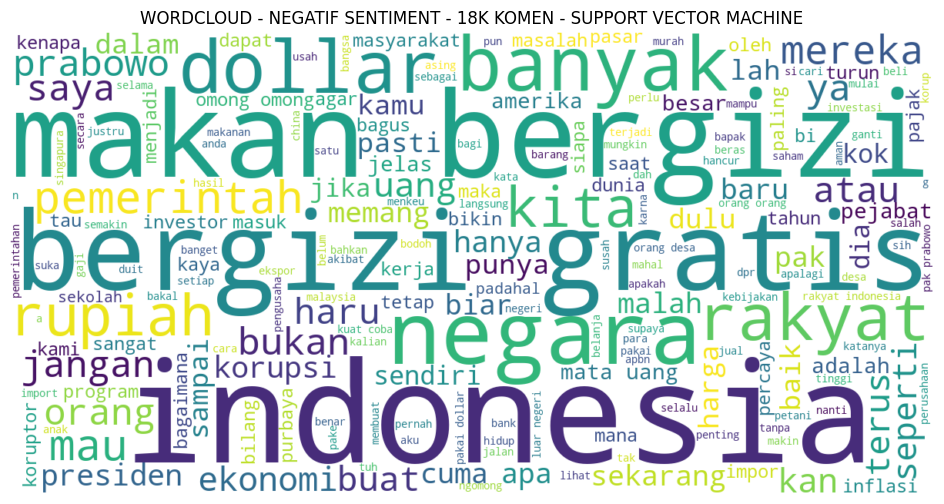

In [17]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

negatif_text = " ".join(
    df_merge[df_merge["sentiment"]== 'negatif']["processed_text"]

)

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    stopwords=custom_stopwords
).generate(negatif_text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("WORDCLOUD - NEGATIF SENTIMENT - 18K KOMEN - SUPPORT VECTOR MACHINE")
plt.show()

In [19]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer()

X_pos = cv.fit_transform(
    df_merge[df_merge["sentiment"]=="positif"]["processed_text"]
    )

pos_freq = pd.DataFrame({
    "word": cv.get_feature_names_out(),
    "freq": X_pos.sum(axis=0).A1
})

pos_freq.sort_values("freq", ascending=False).head(50)



,word,freq
9307,yang,922
2114,di,665
655,apa,495
1971,dan,439
8722,tidak,417
394,ada,395
3518,indonesia,378
1384,bisa,354
9293,ya,344
7594,saya,341


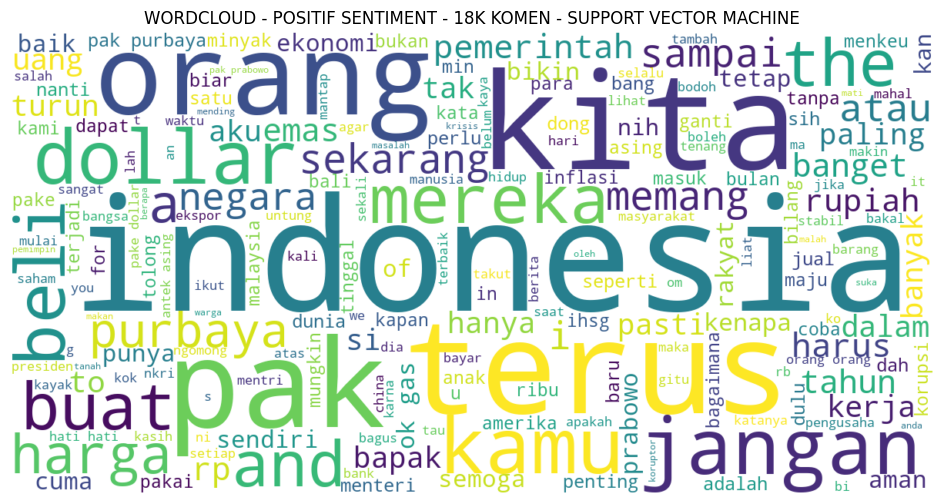

In [22]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

positif_text = " ".join(
    df_merge[df_merge["sentiment"]== 'positif']["processed_text"]

)

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    stopwords=custom_stopwords
).generate(positif_text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("WORDCLOUD - POSITIF SENTIMENT - 18K KOMEN - SUPPORT VECTOR MACHINE")
plt.show()